In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['REEM_MARMAR cv.docx', 'REEM_MARMAR(CV) (1).pdf', 'REEM_MARMAR(CV).pdf', 'الجودة و الرضا (1).gform', 'الجودة و الرضا (Responses) (1).gsheet', 'الجودة و الرضا (Responses).gsheet', 'الجودة و الرضا.gform', 'MWS_WDM_S24_C2_reem_321116_C2_lujain_333673_C2_lujain_333458.ipynb', 'a.docx', 'war-1-1 (2).pptx', 'Colab Notebooks', 'REEM_MARMAR cv.pdf', 'inbound9145471252205811880.jpg', '20250619_115823.jpg', 'rubric_codegrader_qwen_lora', 'rubric_codegrader_qwen_lora_final', 'rubric_codegrader_qwen_lora_5epochs', 'rubric_codegrader_qwen_lora_300samples', 'Master_Project_Dataset', 'rubric_codegrader_qwen_lora_600samples', 'rubric_codegrader_qwen_lora_600samples_epochs8', 'lecture_generation_results', 'qwen_lecture_lora', 'train_data(2).ipynb', 'final_training_dataset.json', 'Qwen_Lecture_Project', 'Copy of new.ipynb', 'training_output', 'qwen3_lecture_adapter', 'after_training.json', 'Test Set', 'evaluation_results_partial.csv', 'Smart_Grading_Assistant_Evaluation.ipynb', 'evaluation_results.csv'

In [ ]:
print(os.listdir('/content/drive/MyDrive/Master_Project_Dataset'))

['Web Programming_Dataset', 'Programming Languages_Dataset', 'Programming1_Dataset']


In [ ]:
import os
import pandas as pd
import json

root = "/content/drive/MyDrive/Master_Project_Dataset"

subjects = [
    "Programming Languages_Dataset",
    "Programming1_Dataset",
    "Web Programming_Dataset"
]

dataset = []
missing = []

def find_student_solution(folder_path, student_id):
    target = student_id.lower()
    for file in os.listdir(folder_path):
        name_without_ext = os.path.splitext(file)[0].lower()
        ext = os.path.splitext(file)[1].lower()

        if name_without_ext == target and ext in [".py", ".cs", ".js"]:
            return os.path.join(folder_path, file)

    return None

for subject in subjects:
    base = os.path.join(root, subject)

    questions_dir = os.path.join(base, "Questions")
    rubrics_dir = os.path.join(base, "Rubrics")
    refs_dir = os.path.join(base, "Reference Solutions")
    grades_dir = os.path.join(base, "Grades")
    solutions_dir = os.path.join(base, "Solutions")

    for question_file in os.listdir(questions_dir):
        qid = question_file.split("_")[0]

        question_path = os.path.join(questions_dir, question_file)

        rubric_file = [f for f in os.listdir(rubrics_dir) if f.startswith(qid)][0]
        reference_file = [f for f in os.listdir(refs_dir) if f.startswith(qid)][0]
        grades_file = [f for f in os.listdir(grades_dir) if f.startswith(qid)][0]
        solution_folder = [f for f in os.listdir(solutions_dir) if f.startswith(qid)][0]

        solution_folder_path = os.path.join(solutions_dir, solution_folder)

        with open(question_path, "r", encoding="utf-8", errors="ignore") as f:
            question_text = f.read()

        with open(os.path.join(rubrics_dir, rubric_file), "r", encoding="utf-8", errors="ignore") as f:
            rubric_text = f.read()

        with open(os.path.join(refs_dir, reference_file), "r", encoding="utf-8", errors="ignore") as f:
            reference_solution = f.read()

        grades_df = pd.read_excel(os.path.join(grades_dir, grades_file))

        for _, row in grades_df.iterrows():
            student_id = str(row["Solution_ID"]).strip()
            grade = row["Grade"]

            student_file = find_student_solution(solution_folder_path, student_id)

            if student_file is None:
                missing.append((subject, qid, student_id))
                continue

            with open(student_file, "r", encoding="utf-8", errors="ignore") as f:
                student_solution = f.read()

            prompt = f"""صحح حل الطالب اعتماداً على السؤال، سلم التصحيح، والحل النموذجي.

المادة: {subject}
رقم السؤال: {qid}

السؤال:
{question_text}

سلم التصحيح:
{rubric_text}

الحل النموذجي:
{reference_solution}

حل الطالب:
{student_solution}

أعطِ العلامة النهائية فقط من 10.
"""

            response = f"العلامة: {grade}/10"

            dataset.append({
                "instruction": "صحح حل الطالب البرمجي اعتماداً على سلم التصحيح والحل النموذجي.",
                "input": prompt,
                "output": response
            })

output_path = "/content/drive/MyDrive/grading_dataset.jsonl"

with open(output_path, "w", encoding="utf-8") as f:
    for sample in dataset:
        f.write(json.dumps(sample, ensure_ascii=False) + "\n")

print("Done")
print("Samples:", len(dataset))
print("Missing:", len(missing))
print("Saved to:", output_path)

if missing:
    print("First missing items:")
    print(missing[:10])

Done
Samples: 600
Missing: 0
Saved to: /content/drive/MyDrive/grading_dataset.jsonl


In [ ]:
path = "/content/drive/MyDrive/grading_dataset.jsonl"

count = 0

with open(path, "r", encoding="utf-8") as f:
    for line in f:
        count += 1

print("Total samples:", count)

Total samples: 600


In [ ]:
path = "/content/drive/MyDrive/grading_dataset.jsonl"

with open(path, "r", encoding="utf-8") as f:
    first = json.loads(next(f))

print(first.keys())
print("\n-----------------\n")
print(first["instruction"])
print("\n-----------------\n")
print(first["output"])

dict_keys(['instruction', 'input', 'output'])

-----------------

صحح حل الطالب البرمجي اعتماداً على سلم التصحيح والحل النموذجي.

-----------------

العلامة: 4/10


In [ ]:
!pip install -q unsloth
!pip install -q transformers datasets accelerate peft trl bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4

In [ ]:
!pip install -q --upgrade --force-reinstall pyarrow==16.1.0 datasets==2.20.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install -q --force-reinstall numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.24.0 requires datasets>=3.0.0, but you have datasets 2.20.0 which is incompatible.
unsloth-zoo 2026.8.10 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 2.20.0 which is incompatible.
unsloth 2026.8.15 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 2.20.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy

In [ ]:
from datasets import load_dataset

dataset_path = "/content/drive/MyDrive/grading_dataset.jsonl"

dataset = load_dataset("json", data_files=dataset_path, split="train")

split_dataset = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Generating train split: 0 examples [00:00, ? examples/s]

Train: 540
Test: 60


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Qwen/Qwen2.5-Coder-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

In [ ]:
def format_example(example):
    text = f"""<|im_start|>system
أنت مساعد ذكي لتصحيح الواجبات البرمجية.
<|im_end|>
<|im_start|>user
{example['instruction']}

{example['input']}
<|im_end|>
<|im_start|>assistant
{example['output']}
<|im_end|>"""
    return {"text": text}

train_dataset = train_dataset.map(format_example)
test_dataset = test_dataset.map(format_example)

print(train_dataset[0]["text"][:1000])

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

<|im_start|>system
أنت مساعد ذكي لتصحيح الواجبات البرمجية.
<|im_end|>
<|im_start|>user
صحح حل الطالب البرمجي اعتماداً على سلم التصحيح والحل النموذجي.

صحح حل الطالب اعتماداً على السؤال، سلم التصحيح، والحل النموذجي.

المادة: Programming1_Dataset
رقم السؤال: Q003

السؤال:
Question_ID: Q003

Title: Student Grade Calculator

Problem Statement: 
Write a C# program that asks the user to enter three exam grades.
The program should calculate the average of the grades and determine the student's letter grade 
according to the following rules:

A : average >= 90
B : average >= 80 and < 90
C : average >= 70 and < 80
D : average >= 60 and < 70
F : average < 60

Display both the average and the letter grade.

Requirements:
1. Read three grades from the user.
2. Calculate the average correctly.
3. Determine the correct letter grade.
4. Display the average.
5. Display the letter grade.
6. Handle boundary values correctly.
7. Organize the code clearly.


سلم التصحيح:
Total: 10 marks

1. Input reading:

In [ ]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

model.gradient_checkpointing_enable()
model.config.use_cache = False

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

def tokenize_function(example):
    result = tokenizer(
        example["text"],
        truncation=True,
        max_length=2048,
        padding="max_length"
    )
    result["labels"] = result["input_ids"].copy()
    return result

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(
    [col for col in tokenized_train.column_names if col not in ["input_ids", "attention_mask", "labels"]]
)

tokenized_test = tokenized_test.remove_columns(
    [col for col in tokenized_test.column_names if col not in ["input_ids", "attention_mask", "labels"]]
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/rubric_codegrader_qwen_lora",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=8,
    learning_rate=2e-4,
    fp16=True,
    gradient_checkpointing=True,
    logging_steps=5,
    save_steps=50,
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

trainer.train()

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Step,Training Loss
5,0.035888
10,0.038684
15,0.051086
20,0.049065
25,0.042022
30,0.043719
35,0.043352
40,0.041737
45,0.038977
50,0.040062


TrainOutput(global_step=1080, training_loss=0.021787857140103974, metrics={'train_runtime': 6493.7369, 'train_samples_per_second': 0.665, 'train_steps_per_second': 0.166, 'total_flos': 6.978967890296832e+16, 'train_loss': 0.021787857140103974, 'epoch': 8.0})

In [ ]:
save_path = "/content/drive/MyDrive/rubric_codegrader_qwen_lora_600samples_epochs8"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/rubric_codegrader_qwen_lora_600samples_epochs8


In [ ]:
from peft import PeftModel

lora_path = "/content/drive/MyDrive/rubric_codegrader_qwen_lora_600samples_epochs8"

model = PeftModel.from_pretrained(model, lora_path)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [ ]:
prompt = """
صحح حل الطالب اعتماداً على السؤال، سلم التصحيح، والحل النموذجي.

السؤال:
اكتب برنامج C# يقرأ رقمين ويطبع مجموعهما.

سلم التصحيح:
قراءة الرقمين: 3 علامات
حساب المجموع: 4 علامات
طباعة الناتج: 3 علامات

الحل النموذجي:
using System;
class Program {
 static void Main() {
  int a = int.Parse(Console.ReadLine());
  int b = int.Parse(Console.ReadLine());
  Console.WriteLine(a + b);
 }
}

حل الطالب:
using System;
class Program {
 static void Main() {
  int a = int.Parse(Console.ReadLine());
  int b = int.Parse(Console.ReadLine());
  Console.WriteLine(a);
 }
}

أعطِ العلامة النهائية فقط من 10.
"""

messages = [
    {"role": "system", "content": "أنت مساعد ذكي لتصحيح الواجبات البرمجية."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False
    )

result = tokenizer.decode(outputs[0], skip_special_tokens=False)
print(result.split("<|im_start|>assistant")[-1])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



العلامة: 6/10
<|im_end|>


In [ ]:
sample = test_dataset[0]

prompt = f"""<|im_start|>system
أنت مساعد ذكي لتصحيح الواجبات البرمجية.
<|im_end|>
<|im_start|>user
{sample['instruction']}

{sample['input']}
<|im_end|>
<|im_start|>assistant
"""

inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)

model.eval()

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
    )

result = tokenizer.decode(outputs[0], skip_special_tokens=False)

print(result.split("<|im_start|>assistant")[-1])
print("Expected:", sample["output"])


العلامة: 6/10
<|im_end|>
Expected: العلامة: 6/10


In [ ]:
for i in range(5):
    sample = test_dataset[i]

    prompt = f"""<|im_start|>system
أنت مساعد ذكي لتصحيح الواجبات البرمجية.
<|im_end|>
<|im_start|>user
{sample['instruction']}

{sample['input']}
<|im_end|>
<|im_start|>assistant
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False
        )

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=False)
    prediction = prediction.split("<|im_start|>assistant")[-1].strip()

    print("="*50)
    print("Prediction:", prediction)
    print("Expected:", sample["output"])

Prediction: العلامة: 6/10
<|im_end|>
Expected: العلامة: 6/10
Prediction: العلامة: 3/10
<|im_end|>
Expected: العلامة: 3/10
Prediction: العلامة: 5/10
<|im_end|>
Expected: العلامة: 5/10
Prediction: العلامة: 7/10
<|im_end|>
Expected: العلامة: 6/10
Prediction: العلامة: 10/10
<|im_end|>
Expected: العلامة: 10/10


In [ ]:
import re
import torch

def extract_score(text):
    match = re.search(r"(\d+(?:\.\d+)?)\s*/\s*10", str(text))
    if match:
        return float(match.group(1))
    return None

correct = 0
evaluated = 0
total = len(test_dataset)

model.eval()

for i in range(total):
    sample = test_dataset[i]

    prompt = f"""<|im_start|>system
أنت مساعد ذكي لتصحيح الواجبات البرمجية.
<|im_end|>
<|im_start|>user
{sample['instruction']}

{sample['input']}
<|im_end|>
<|im_start|>assistant
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # نفك فقط التوكنات الجديدة التي ولدها النموذج
    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]

    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    pred_score = extract_score(prediction)
    true_score = extract_score(sample["output"])

    if pred_score is not None and true_score is not None:
        evaluated += 1

        if pred_score == true_score:
            correct += 1
    else:
        print(
            f"Sample {i} skipped:",
            "Prediction =", repr(prediction),
            "| Expected =", repr(sample["output"])
        )

accuracy = correct / evaluated if evaluated > 0 else 0

print("Exact Accuracy:", accuracy)
print("Exact Accuracy %:", accuracy * 100)
print("Correct predictions:", correct)
print("Evaluated samples:", evaluated)
print("Skipped samples:", total - evaluated)

Exact Accuracy: 0.55
Exact Accuracy %: 55.00000000000001
Correct predictions: 33
Evaluated samples: 60
Skipped samples: 0


In [ ]:
pred_scores = []
true_scores = []

def extract_score(text):
    match = re.search(r"(\d+(?:\.\d+)?)\s*/\s*10", text)
    if match:
        return float(match.group(1))
    return None

for i in range(len(test_dataset)):
    sample = test_dataset[i]

    prompt = f"""<|im_start|>system
أنت مساعد ذكي لتصحيح الواجبات البرمجية.
<|im_end|>
<|im_start|>user
{sample['instruction']}

{sample['input']}
<|im_end|>
<|im_start|>assistant
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False
        )

    pred_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    pred_text = pred_text.split("<|im_start|>assistant")[-1]
    pred_text = pred_text.replace("<|im_end|>", "").strip()

    pred_score = extract_score(pred_text)
    true_score = extract_score(sample["output"])

    if pred_score is not None and true_score is not None:
        pred_scores.append(pred_score)
        true_scores.append(true_score)

mae = sum(abs(p - t) for p, t in zip(pred_scores, true_scores)) / len(true_scores)

print("MAE:", mae)
print("MAE % of 10:", mae * 10)
print("Evaluated samples:", len(true_scores))

MAE: 0.5666666666666667
MAE % of 10: 5.666666666666666
Evaluated samples: 60


In [ ]:
within_one = 0
total = len(true_scores)

for p, t in zip(pred_scores, true_scores):
    if abs(p - t) <= 1:
        within_one += 1

within_one_accuracy = within_one / total if total > 0 else 0

print("Within ±1 Accuracy:", within_one_accuracy)
print("Within ±1 Accuracy %:", within_one_accuracy * 100)
print("Samples within ±1:", within_one)
print("Evaluated samples:", total)

Within ±1 Accuracy: 0.9166666666666666
Within ±1 Accuracy %: 91.66666666666666
Samples within ±1: 55
Evaluated samples: 60


In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.metrics import mean_squared_error
import math

if len(true_scores) > 0:
    rmse = math.sqrt(mean_squared_error(true_scores, pred_scores))

    print("RMSE:", rmse)
    print("Evaluated samples:", len(true_scores))
    print("Skipped samples:", len(test_dataset) - len(true_scores))
else:
    print("No valid samples found.")

RMSE: 0.9309493362512627
Evaluated samples: 60
Skipped samples: 0


In [ ]:
from sklearn.metrics import cohen_kappa_score

qwk = cohen_kappa_score(
    true_int,
    pred_int,
    weights="quadratic"
)

print("Quadratic Weighted Kappa (QWK):", qwk)
print("Evaluated samples:", len(true_scores))

Quadratic Weighted Kappa (QWK): 0.8946159562250895
Evaluated samples: 60


In [ ]:
!pip install scipy

In [ ]:
from scipy.stats import pearsonr

if len(true_scores) > 1:
    pearson_corr, p_value = pearsonr(true_scores, pred_scores)

    print("Pearson Correlation:", pearson_corr)
    print("P-value:", p_value)
    print("Evaluated samples:", len(true_scores))
else:
    print("Not enough samples to calculate Pearson Correlation.")

Pearson Correlation: 0.896896369660636
P-value: 3.2514588746450173e-22
Evaluated samples: 60


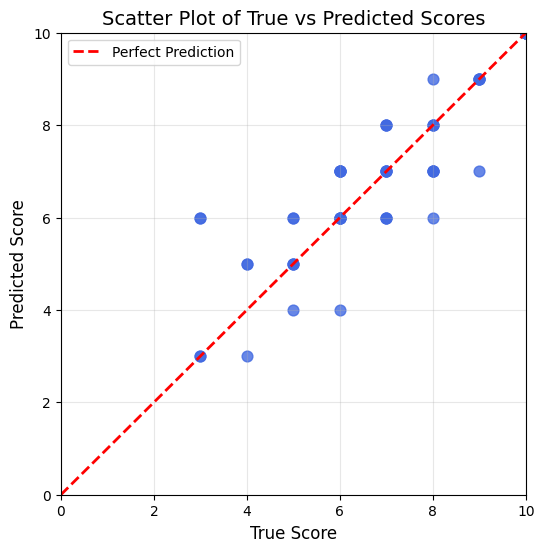

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(true_scores, pred_scores,
            color="royalblue",
            s=60,
            alpha=0.8)

plt.plot([0,10], [0,10],
         "r--",
         linewidth=2,
         label="Perfect Prediction")

plt.xlabel("True Score", fontsize=12)
plt.ylabel("Predicted Score", fontsize=12)
plt.title("Scatter Plot of True vs Predicted Scores", fontsize=14)

plt.xlim(0,10)
plt.ylim(0,10)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

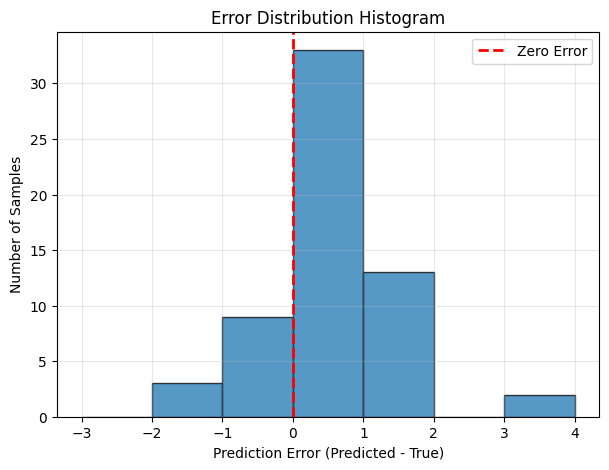

In [ ]:
import matplotlib.pyplot as plt

# حساب الأخطاء
errors = [p - t for p, t in zip(pred_scores, true_scores)]

plt.figure(figsize=(7,5))

plt.hist(errors, bins=range(-3,5), edgecolor="black", alpha=0.75)

plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")

plt.title("Error Distribution Histogram")
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Number of Samples")

plt.grid(alpha=0.3)
plt.legend()

plt.show()